# 第 2 章实验：不可导前向与 Straight-Through Estimator

这份 Notebook 沿用第 1 章的 NumPy `Tensor` 引擎。我们先把链式法则和 Jacobian 用小数字摊开，再亲眼观察 `round` 的有限差分梯度为何为零，最后实现 fake quantization 的三种反向规则，并用 PyTorch 与训练曲线验证它们。

完整实现位于同目录的 `quantization.py`、`experiment.py` 与 `plot_ch02.py`

## 0. 环境与可复现性

全部实验使用 CPU 和 `float64`。固定随机种子后，相同环境会得到相同的数据、初始化和曲线。

In [1]:
from pathlib import Path
import importlib
import inspect
import sys

import numpy as np
import torch
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "code" / "ch02").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("请从本仓库内运行 Notebook")
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
ASSET_DIR = REPO_ROOT / "assets" / "ch02"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

cached_code = sys.modules.get("code")
if cached_code is not None and not hasattr(cached_code, "__path__"):
    del sys.modules["code"]
importlib.invalidate_caches()

from code.ch01.tensor import Tensor
from code.ch02.experiment import run_training_comparison
from code.ch02.plot_ch02 import generate_all_plots
from code.ch02.quantization import fake_quantize, torch_identity_ste

np.set_printoptions(precision=6, suppress=True)
print(f"NumPy {np.__version__} | PyTorch {torch.__version__} | root={REPO_ROOT.name}")

NumPy 1.26.4 | PyTorch 2.2.2 | root=ai-engineering-deepdive


## 1. 一个数先走完前向，再决定怎样反向

令 $x=0.74$、$s=0.5$、整数码范围 $[-2,2]$。量化码为 $q=\operatorname{clip}(\operatorname{round}(x/s),-2,2)=1$，反量化值为 $\hat x=sq=0.5$。前向已经确定；争议只发生在反向：真实导数几乎处处为 0，identity STE 传 1，clipped STE 只在未饱和时传 1。

In [2]:
x_value, scale, qmin, qmax = 0.74, 0.5, -2, 2
integer_code = np.clip(np.round(x_value / scale), qmin, qmax)
dequantized = integer_code * scale
print(f"x={x_value}, x/scale={x_value/scale:.2f}, q={integer_code:.0f}, fake-quant={dequantized:.2f}")

def scalar_fake_quant(value):
    return np.clip(np.round(value / scale), qmin, qmax) * scale

for epsilon in (1e-2, 1e-4, 1e-6):
    finite_difference = (
        scalar_fake_quant(x_value + epsilon) - scalar_fake_quant(x_value - epsilon)
    ) / (2 * epsilon)
    print(f"epsilon={epsilon:.0e}, 中心差分={finite_difference:.1f}")

x=0.74, x/scale=1.48, q=1, fake-quant=0.50
epsilon=1e-02, 中心差分=25.0
epsilon=1e-04, 中心差分=0.0
epsilon=1e-06, 中心差分=0.0


## 2. 链式法则从标量到 Jacobian

取 $f(x_1,x_2)=(x_1x_2, x_1+x_2^2)$，在 $(2,3)$ 处，完整 Jacobian 是 $\begin{bmatrix}3&2\\1&6\end{bmatrix}$。若后续标量目标给出的上游梯度是 $g_y=(4,-1)$，reverse mode 传播的是 $J^Tg_y=(11,2)$，不需要把大型网络的 Jacobian 真正存下来。

In [3]:
jacobian = np.array([[3.0, 2.0], [1.0, 6.0]])
upstream = np.array([4.0, -1.0])
vjp = jacobian.T @ upstream
print("J =")
print(jacobian)
print("g_y =", upstream)
print("J^T g_y =", vjp)

J =
[[3. 2.]
 [1. 6.]]
g_y = [ 4. -1.]
J^T g_y = [11.  2.]


## 3. 同一个 fake-quant 前向，三种 backward

下面直接查看并调用仓库里的实现。`zero` 忠实使用阶梯函数几乎处处为零的导数；`identity` 无条件复制上游梯度；`clipped` 仅当 round 后、clamp 前的整数码仍在范围内时复制梯度。

In [4]:
print(inspect.getsource(fake_quantize))
values = np.array([-1.26, -1.24, -0.25, 0.74, 1.24, 1.26])
for mode in ("zero", "identity", "clipped"):
    node = Tensor(values)
    output = fake_quantize(node, 0.5, -2, 2, grad_mode=mode)
    output.sum().backward()
    print(f"{mode:>8} | forward={output.data} | grad={node.grad}")

def fake_quantize(
    tensor: Tensor,
    scale: float,
    qmin: int,
    qmax: int,
    *,
    grad_mode: GradientMode = "clipped",
) -> Tensor:
    """用真实阶梯前向与指定 surrogate gradient 构造伪量化节点。

    ``zero`` 使用分段常数函数几乎处处为零的真实导数；``identity``
    原样复制上游梯度；``clipped`` 仅在未发生整数码饱和时复制梯度。
    scale 和量化边界在本章视为固定超参数，不参与求导。
    """

    _validate_quantization_parameters(scale, qmin, qmax, grad_mode)              # 验证量化参数的有效性，包括 scale、qmin、qmax 的合法性和 grad_mode 的有效性
    data, integer_codes = quantize_dequantize(tensor.data, scale, qmin, qmax)    # 对伪量化值和整数码进行计算，其中整数码用于后续的梯度掩码判据
    output = Tensor(                                                             # 构建伪量化节点，包含前向的真实阶梯量化和反向的代理梯度 
        data,
        (tensor,),
        f"fake_quant[{grad_mode}]",
        requires_grad=tensor.requires_grad,
    )

    def _backward() -> None:
        if grad_mode == "zero":                                                  # 在 zero 模式下，梯度不传播，用于模拟分段常数量化函数的零导数特性
            return
        if grad_mode == "ide

## 4. 与 PyTorch 官方 fake-quant 对拍

PyTorch 官方算子采用仿射 fake quantization。这里把 zero point 固定为 0，使它退化为与本章完全相同的对称 per-tensor 量化；比较前向结果和 clipped backward mask。

In [5]:
ours_x = Tensor(values)
ours_y = fake_quantize(ours_x, 0.5, -2, 2, grad_mode="clipped")
ours_y.sum().backward()

torch_x = torch.tensor(values, dtype=torch.float64, requires_grad=True)
torch_y = torch.fake_quantize_per_tensor_affine(torch_x, 0.5, 0, -2, 2)         # 使用 PyTorch 内置的伪量化函数，参数依次为输入张量、缩放因子、零点、最小值、最大值
torch_y.sum().backward()
print("前向最大绝对误差：", np.max(np.abs(ours_y.data - torch_y.detach().numpy())))
print("反向最大绝对误差：", np.max(np.abs(ours_x.grad - torch_x.grad.numpy())))

前向最大绝对误差： 0.0
反向最大绝对误差： 0.0


## 5. detach-trick 为什么能分离前向与反向

表达式 `x + (Q(x) - x).detach()` 的数值等于 $Q(x)$；反向时括号内整条路径已 detach，只剩 `x` 的恒等路径。因此它是 identity STE 的紧凑写法，不是让 `round` 突然拥有了真实导数。

In [6]:
detach_x = torch.tensor([-0.74, 0.26, 1.8], dtype=torch.float64, requires_grad=True)
detach_y = torch_identity_ste(detach_x, 0.5, -2, 2)
detach_y.sum().backward()
print("forward:", detach_y.detach().numpy())
print("backward:", detach_x.grad.numpy())

forward: [-0.5  0.5  1. ]
backward: [1. 1. 1.]


## 6. 训练对照：错误的 forward 还是不可用的 backward？

四组实验共享数据、初始化、学习率和步数。`zero` 组的参数梯度始终为零；另外三组拥有可用更新方向。这里的 loss 是 MSE、标签为 $-1/+1$，小模型只有一个二维线性层和 `tanh`。

In [7]:
results = run_training_comparison()
print("mode      loss(first -> last)   acc(first -> last)   update-norm")
for mode, result in results.items():
    print(
        f"{mode:>8}  {result.losses[0]:.6f} -> {result.losses[-1]:.6f}   "
        f"{result.accuracies[0]:.4f} -> {result.accuracies[-1]:.4f}   "
        f"{result.weight_update_norm:.6f}"
    )

mode      loss(first -> last)   acc(first -> last)   update-norm
   float  1.122013 -> 0.007870   0.1750 -> 1.0000   1.642957
    zero  1.561006 -> 1.561006   0.0063 -> 0.0063   0.000000
identity  1.561006 -> 0.013024   0.0063 -> 1.0000   1.696134
 clipped  1.561006 -> 0.013024   0.0063 -> 1.0000   1.627043


## 7. 真实图表

第一张图把“相同前向、不同反向”画在一起；第二张图展示无 STE 时训练曲线完全冻结，而 identity/clipped STE 能让量化前向参与训练。

assets/ch02/ste_forward_backward.png
assets/ch02/training_comparison.png


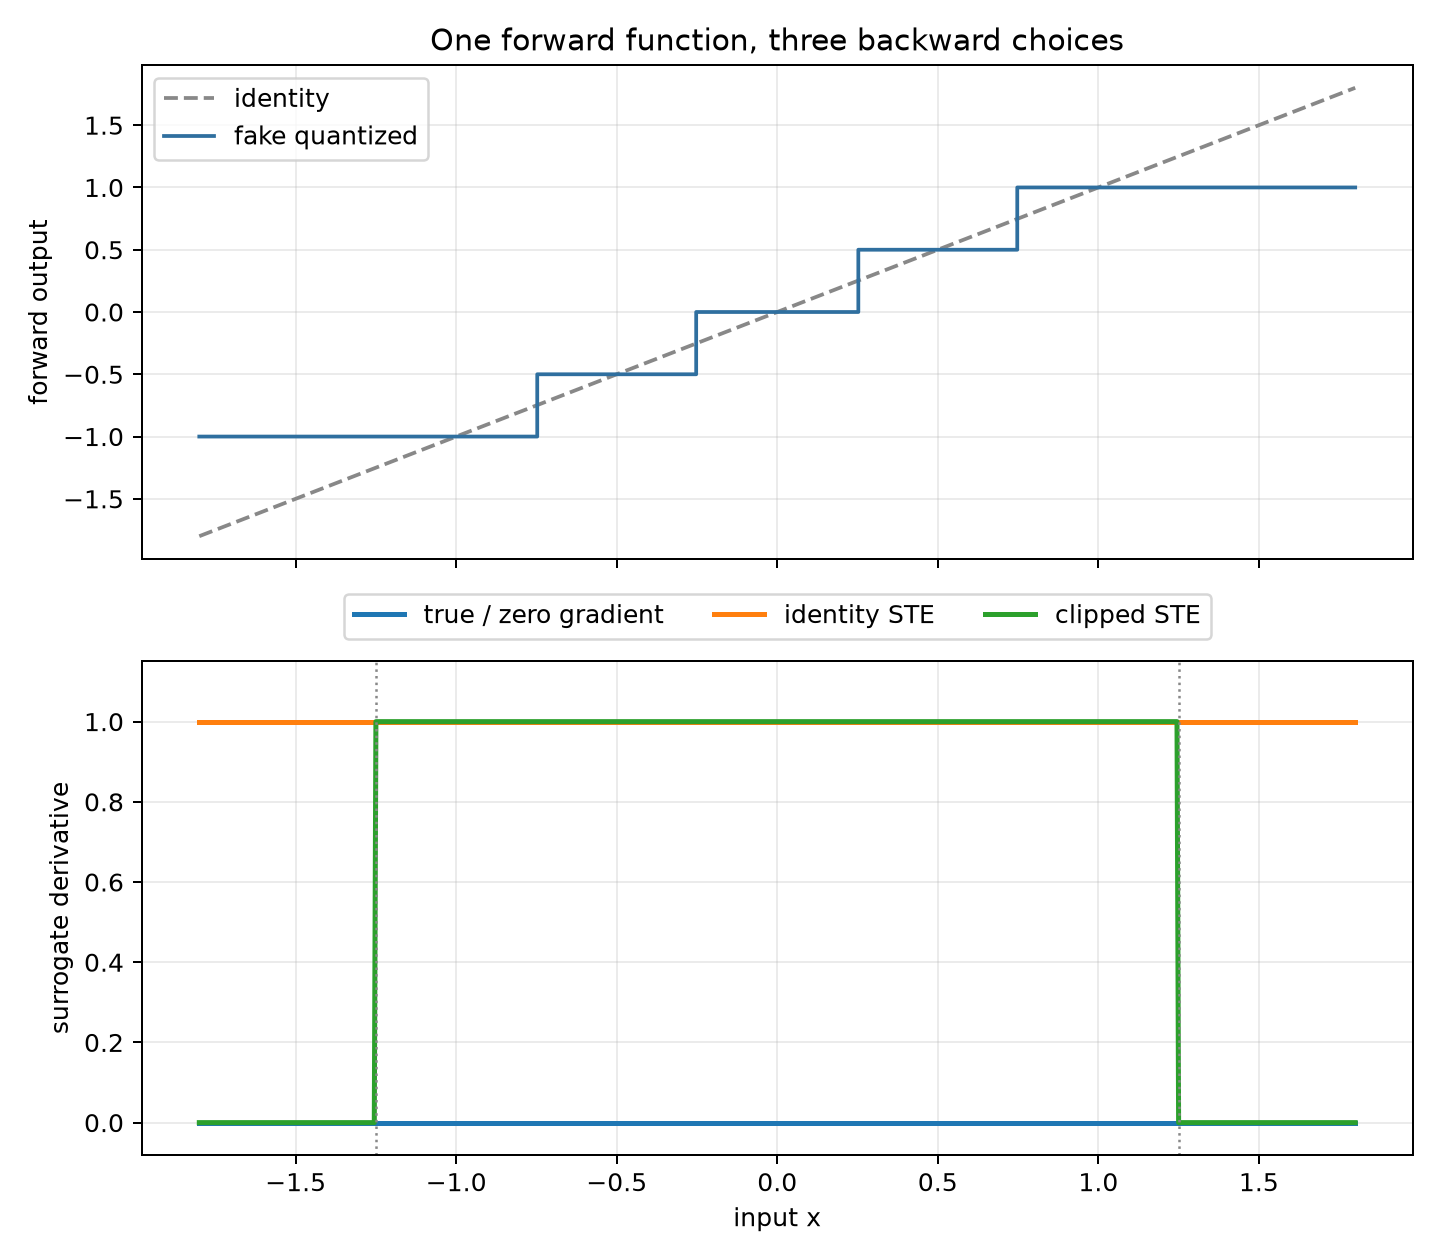

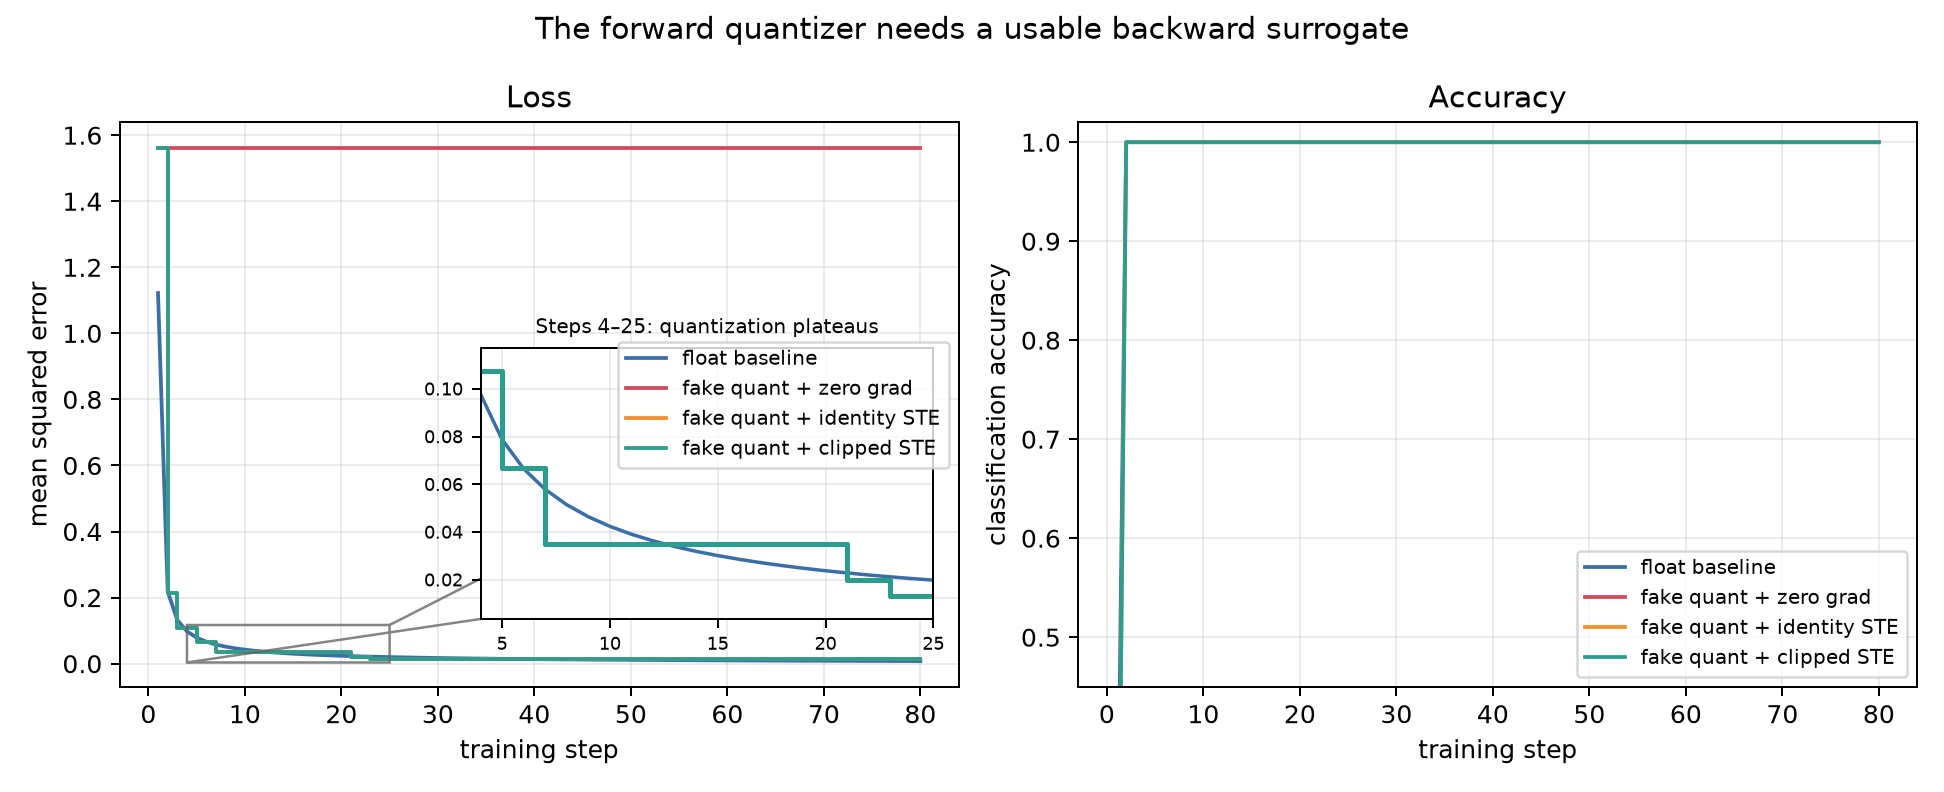

In [8]:
generated = generate_all_plots(ASSET_DIR)
for path in generated:
    print(path.relative_to(REPO_ROOT))
display(Image(filename=str(ASSET_DIR / "ste_forward_backward.png"), width=720))
display(Image(filename=str(ASSET_DIR / "training_comparison.png"), width=900))

## 8. 建议改造

1. 把 scale 从 0.25 改成 0.5 或 0.125，记录量化网格粗细怎样改变最终 loss。
2. 把 `clipped` 的 mask 故意改成对反量化端点直接比较，观察哪个 PyTorch 对拍用例会失败。
3. 为非零 zero point 扩展仿射量化；先写手算前向和官方对拍测试，再改实现。
4. 将输入激活也 fake quantize，比较只量化权重与权重/激活同时量化的差别。